# Examen 1: Fundamentos de probabilidad

## Parte I: Diagn´ostico de Cartera y Comportamiento del Cliente

## Parte II: An´alisis de Variables Aleatorias Continuas

In [5]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [6]:
# Lectura del dataframe
df = pd.read_csv("data/raw/credit_risk_data.csv")
df.tail()

,ID_Cliente,Ingreso_Mensual,Tipo_Vivienda,Mora_Previa,Estado_Credito,Puntaje_Psicometrico
9995,FT-09996,4.67,Propia,0,0,77
9996,FT-09997,3.98,Propia,0,1,63
9997,FT-09998,1.47,Alquilada,0,1,39
9998,FT-09999,6.27,Propia,0,0,74
9999,FT-10000,2.34,Alquilada,0,0,68


In [7]:
# chequeamos si hay valores nulos en los datos
df.isnull().sum()

ID_Cliente              0
Ingreso_Mensual         0
Tipo_Vivienda           0
Mora_Previa             0
Estado_Credito          0
Puntaje_Psicometrico    0
dtype: int64

¿los datos muestran una asimetría clara: hay muchos clientes con
ingresos bajos y pocos con ingresos muy altos?

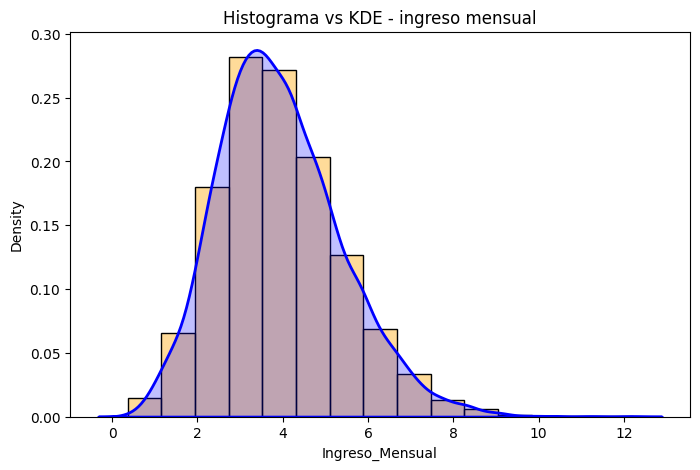

In [13]:
#ingreso_X = df["Ingreso_Mensual"].dropna()

ingreso_X = df["Ingreso_Mensual"]

plt.figure(figsize=(8, 5))
# Nota: stat="density" escala el histograma para que el área total sea 1 (probabilidad)
sns.histplot(data=ingreso_X, bins='sturges', color="orange", stat="density", alpha=0.4)
sns.kdeplot(data=ingreso_X, color="blue", bw_adjust=1.0, linewidth=2, fill=True)
plt.title("Histograma vs KDE - ingreso mensual")
plt.show()

Segun la gráfica y la distribución de los datos de ingresos mensuales, se observa una asimetría posistiva y se ve una **mayor concentración** de personas con ingresos medios y bajos entre 2 mil y 5 mil USD y se observa claramete que hay **pocas personas** con ingresos altos. 

1. Estime el valor esperado E[X] y la varianza Var(X) de los ingresos de la cartera total. 
¿Qué nos dice la diferencia entre la media y la mediana sobre la equidad de los ingresos en esta muestra?

In [14]:
# Estimación de la Esperanza Matemática (Media Muestral)
# Utilizamos numpy
esperanza_X = np.mean(ingreso_X)

# Estimación de la Varianza
# El parámetro ddof=1 asegura la corrección de grados de libertad (N-1)
varianza_X = np.var(ingreso_X, ddof=1)

# Cálculo de la Mediana (Percentil 50) para análisis de sesgo
mediana_X = np.median(ingreso_X)

# Impresión de resultados
print(f"Esperanza Matemática E[X] (Media): {esperanza_X:.2f} miles de USD")
print(f"Varianza Var(X): {varianza_X:.2f} (miles de USD)^2")
print(f"Mediana (Percentil 50): {mediana_X:.2f} miles de USD")

Esperanza Matemática E[X] (Media): 3.92 miles de USD
Varianza Var(X): 2.09 (miles de USD)^2
Mediana (Percentil 50): 3.77 miles de USD


Dado que E[X]=3.92 es mayor que la mediana de 3.77, estamos frente a una distribución con asimetría positiva (sesgada a la derecha). Matemáticamente, significa que el 50% de los clientes gana 3.77 o menos, pero existe una minoría de clientes (una "cola" en la distribución) con ingresos considerablemente altos que terminan arrastrando el promedio matemático hacia arriba. Por lo tanto, hay una ligera inequidad: el "cliente promedio" matemático gana más que la mayoría real de la población.

2. Suponiendo que el ingreso sigue una distribución continua, aproxime la probabilidad de que un solicitante elegido al azar tenga un ingreso entre 3.0 y 5.0 mil USD

In [15]:
# Definición de los límites del intervalo
limite_inferior = 3.0
limite_superior = 5.0

# Filtro lógico (Máscara booleana)
# Evaluamos qué registros cumplen ambas condiciones simultáneamente
en_rango = (ingreso_X >= limite_inferior) & (ingreso_X <= limite_superior)

# Cálculo frecuentista de la probabilidad
# La media de un vector de booleanos (1s y 0s) equivale matemáticamente a la proporción de casos favorables
probabilidad_rango = np.mean(en_rango)

print(f"La probabilidad estimada P[3.0 <= X <= 5.0] es: {probabilidad_rango:.4f} (o {probabilidad_rango * 100:.2f}%)")

La probabilidad estimada P[3.0 <= X <= 5.0] es: 0.5108 (o 51.08%)


Obtener un 51.08% nos indica que un poco más de la mitad de toda nuestra cartera de clientes se concentra en esa banda salarial estable de 3 a 5 mil USD. Este resultado se evidencia en el gráfico de densidad expuesto en punto anterior donde vemos una alta concetración de clientes en estos rangos

3. La empresa desea lanzar un producto “Premium” dirigido exclusivamente al 15 % de los clientes con mayores ingresos.
¿A partir de qué monto de ingreso mensual debería enviarse la invitación a este producto?

In [16]:
# Definimos el cuantil objetivo 
# Si queremos el 15% superior, buscamos el percentil 85 (0.85)
q = 0.85

# Estimación del cuantil empírico
# np.quantile ordena los datos bajo el capó y encuentra el valor de corte exacto
ingreso_premium = np.quantile(ingreso_X, q)

print(f"El umbral para enviar la invitación Premium (Percentil 85) es: {ingreso_premium:.2f} miles de USD")

El umbral para enviar la invitación Premium (Percentil 85) es: 5.41 miles de USD


Reflexión: Si el valor esperado E[X] es significativamente mayor que el ingreso del 50 % de la población, ¿considera
usted que la media es un indicador confiable para diseñar productos masivos, o debería la empresa basarse en los cuantiles
para entender a su cliente promedio?

Respuesta: **No se puede** considerar la media como un indicador confiable para diseñar productos masivos ya que la media se ve afectada por los valores mas altos; en este caso, ingresos muy altos de pocas personas, lo que hace que los productos diseñados se dirijan hacia publicos con muy pocas personas. Es aconsejable usar los cuantiles 

## Parte III: Clasificaci´on y Funciones de Densidad